# Pricing & Discount Optimization Analysis
## A Revenue and Margin Analysis of Retail Discounting

**Dataset:** Online Retail II - UCI (1M+ transactions, 2009-2011)

**Tools:** Python, pandas, matlplotlib, seaborn, scipy, SQLite, Power BI

**Author:** AVALA NAGA VENKATA SASI KUMAR | JUNE 2026
____

##  Business Problem 

A retail company offers frequent discounts across product categories.
While discounting drives volume, it is unclear whether it improves overall profitability or erodes margin.

The analysis answers:
1. What is the relationship between discount depth and revenue?
2. At what discount % does margin start to erode?
3. Which categories respond best to discounting (elastic demand)?
4. Is the revenue lift from discounting statistically significant?
5. What is the optimal discount tier per category?

----

## KPIs
- KPI 1: Average revenue per transaction by discount tier
- KPI 2: Margin score (revenue * (1 - discount_pct)) by category
- KPI 3: Price elasticity per product category
- KPI 4: A/B test p-value (discounted vs non-discounted transactions)
___

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries loaded!")

All libraries loaded!


In [3]:
df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/online_retail_II.csv", encoding='unicode_escape')

print("shape:",df.shape)
print("\ncolumns:",df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

shape: (1067371, 8)

columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 3 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom


In [4]:
print("shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSample rows:")
df.head(5)

shape: (1067371, 8)

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Sample rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [5]:
# Check for cancellations (Invoice starts with 'C')
cancellations = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"Cancellation rows: {len(cancellations):,}")

# Check for negative quantities
neg_qty = df[df['Quantity'] < 0]
print(f"Negative quantity rows: {len(neg_qty):,}")

# Check for zero or negative prices
bad_price = df[df['Price'] <= 0]
print(f"Zero/negative price rows: {len(bad_price):,}")

# Check unique countries
print(f"\nUnique countries: {df['Country'].nunique()}")
print(df['Country'].value_counts().head(5))

Cancellation rows: 19,494
Negative quantity rows: 22,950
Zero/negative price rows: 6,207

Unique countries: 43
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Name: count, dtype: int64


___
## Data Quality Issues Found
This dataset has 3 specific problems that must be fixed beefore analysis:
1. Cancellation rows (Invoice starts with 'C') - not real sales.
2. Negative quantities - returns/refunds.
3. Zero prices - test entries or free items, not real transactions

In [6]:
print(f"Rows before cleaning: {len(df):,}")

# Step 1: Remove cancellation invoices
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {len(df):,}")

# Step 2: Keep only positive quantities (real sales)
df = df[df['Quantity'] > 0]
print(f"After removing negative qty: {len(df):,}")

# Step 3: Keep only positive prices (real transactions)
df = df[df['Price'] > 0]
print(f"After removing zero prices: {len(df):,}")

# Step 4: Drop rows with missing description
df = df.dropna(subset=['Description'])
print(f"After dropping missing descriptions: {len(df):,}")

Rows before cleaning: 1,067,371
After removing cancellations: 1,047,877
After removing negative qty: 1,044,420
After removing zero prices: 1,041,670
After dropping missing descriptions: 1,041,670


**The ~ symbol means NOT. so df[~ condition] keeps rows where the condition is FALSE. This is how you EXCLUDE rows in pandas.**

In [7]:
# Check how many Customer IDs are missing
missing_cust = df['Customer ID'].isnull().sum()
total = len(df)
print(f"Missing Customer IDs: {missing_cust:,} ({missing_cust/total*100:.1f}%)")

# Fill missing Customer IDs with 'Unknown'
# we keep these rows - they still have valid transaction data
df['Customer ID'] = df['Customer ID'].fillna('Unknown')
df['Customer ID'] = df['Customer ID'].astype(str)

print("Missing Customer IDs after fill", df['Customer ID'].isnull().sum())

Missing Customer IDs: 236,121 (22.7%)
Missing Customer IDs after fill 0


*Here ~25% ofCustomer IDs are missing.Dropping them would loose too much data. We fill with 'Unknown' and keep them - these are still real transactions woth valid price and quality data for our discount analysis.*

In [8]:
# Convert InvoiceDate to proper datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Month and Year for the time analysis later
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

print("Date range:", df['InvoiceDate'].min(),"to",df['InvoiceDate'].max())
print("sample dates:", df[['InvoiceDate','Month','Year','MonthYear']].head(3))

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
sample dates:           InvoiceDate  Month  Year MonthYear
0 2009-12-01 07:45:00     12  2009   2009-12
1 2009-12-01 07:45:00     12  2009   2009-12
2 2009-12-01 07:45:00     12  2009   2009-12


## Feature Engineering

In [9]:
# Revenue = units sold * price paid
df['Revenue'] = df['Quantity'] * df['Price']

print(f"Total Revenue in dataset: £{df['Revenue'].sum():,.2f}")
print(f"Avg revenue per transaction: £{df['Revenue'].mean():.2f}")
print(f"Revenue range: £{df['Revenue'].min():.2f} to £{df['Revenue'].max():,.2f}")

Total Revenue in dataset: £20,972,594.57
Avg revenue per transaction: £20.13
Revenue range: £0.00 to £168,469.60


***This is a simple multiplication - but this is the most important column in the project.***

*Every chart and KPI is built on this*

*Hence the **Total_Revenue: £19,287,250.57** .*

In [10]:
# Standard price = median selling price for each product
standard_prices = df.groupby('StockCode')['Price'].median()
standard_prices.name = 'Standard_Price'

# Merge back into main dataframe
df = df.merge(standard_prices, on='StockCode', how='left')

print(f"Standard price calculated for {len(standard_prices):,} products")
print("\nSample:")
df[['StockCode','Description','Price','Standard_Price']].head(5)

Standard price calculated for 4,917 products

Sample:


,StockCode,Description,Price,Standard_Price
0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,6.95,7.95
1,79323P,PINK CHERRY LIGHTS,6.75,6.75
2,79323W,WHITE CHERRY LIGHTS,6.75,6.75
3,22041,"RECORD FRAME 7"" SINGLE SIZE",2.10,2.55
4,21232,STRAWBERRY CERAMIC TRINKET BOX,1.25,1.25


**We use MEDIAN not MEAN, as the Standard Price.**

Because Median is more robust to extreme outliers. A single bulk order at a very high price won't distrot the standard price the way it would with a mean.

In [11]:
# Discount % = how far below standard price was this transaction?
df['Discount_Pct'] = ( (df['Standard_Price'] - df['Price']) / df['Standard_Price'] * 100).round(2)

# Cap at 0 on the lower end (negative = premium pricing, treat as 0 discount)
# Cap at 80 on the upper end (>80% discount = likely data error)
df['Discount_Pct'] = df['Discount_Pct'].clip(lower=0, upper=80)

print("Discount % distribution:")
print(df['Discount_Pct'].describe().round(2))
print(f"\nTransactions with any discount: {(df['Discount_Pct'] > 0).sum():,}")

Discount % distribution:
count   1041670.00
mean          2.78
std          11.02
min           0.00
25%           0.00
50%           0.00
75%           0.00
max          80.00
Name: Discount_Pct, dtype: float64

Transactions with any discount: 106,223


***.clip(lower=0,upper=80) limits value to the range [0,80]. Values below 0 become 0 (no discount), Values above 80 become 80 (capped - extreme values are likely data errors).***

**This is called "winsorizing" and is standard practice in pricing analysis.**

In [12]:
# Bin discount % into 4 tiers
bins = [-1, 0, 10, 25, 80]
labels = ['No Discount', 'Low (1-10%)', 'Medium (11-25%)', 'High (25%+)']

df['Discount_Tier'] = pd.cut(
    df['Discount_Pct'],
    bins=bins,
    labels=labels
)

print("Transactions per discount tier:")
print(df['Discount_Tier'].value_counts())
print("\nPercentage Split:")
print((df['Discount_Tier'].value_counts(normalize=True)*100).round(1))

Transactions per discount tier:
Discount_Tier
No Discount        935447
Medium (11-25%)     47266
High (25%+)         37197
Low (1-10%)         21760
Name: count, dtype: int64

Percentage Split:
Discount_Tier
No Discount       89.80
Medium (11-25%)    4.50
High (25%+)        3.60
Low (1-10%)        2.10
Name: proportion, dtype: float64


**pd.cut() divides a continuous variable (Discount_Pct) into discrete buckets (bins).**

bins=[-1,0,10,25,80] creates 4 ranges: (-1 to 0], (0 to 10], (10 to 25], (25 to 80]. 

The -1 lower bound ensures 0% discounts are captured. 
            
**This is called "binning" — a core feature engineering technique.**

In [13]:
# Margin Score = revenue adjusted for discount depth
# Higher discount = lower margin score even if revenue is high

df['Margin_Score'] = (df['Revenue'] * (1 - df['Discount_Pct'] / 100)).round(2)

print("Margin Score summary by Discount Tier:")
print(df.groupby('Discount_Tier')['Margin_Score'].agg(['mean','sum']).round(2))

Margin Score summary by Discount Tier:
                 mean         sum
Discount_Tier                    
No Discount     14.68 13731754.73
Low (1-10%)     36.56   795581.76
Medium (11-25%) 91.05  4303593.49
High (25%+)     18.58   691187.50


In [14]:
print("=== FINAL DATASET HEALTH CHECK ===")
print(f"Total rows             : {len(df):,}")
print(f"Total columns          : {df.shape[1]}")
print(f"Missing values         : {df.isnull().sum()}")
print(f"Date range             : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Unique Products        : {df['StockCode'].nunique():,}")
print(f"Unique customers       : {df['Customer ID'].nunique():,}")
print(f"Total revenue          : £{df['Revenue'].sum():,.2f}")
print(f"Avg discount %         : {df['Discount_Pct'].mean():.1f}%")
print(f"\n New columns created : Revenue, Standard_Price,")
print(f" Discount_Pct, Discount_Tier, Margin_Score")
print("\n Discount tier split:")
print(df['Discount_Tier'].value_counts())

=== FINAL DATASET HEALTH CHECK ===
Total rows             : 1,041,670
Total columns          : 16
Missing values         : Invoice           0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
Price             0
Customer ID       0
Country           0
Month             0
Year              0
MonthYear         0
Revenue           0
Standard_Price    0
Discount_Pct      0
Discount_Tier     0
Margin_Score      0
dtype: int64
Date range             : 2009-12-01 → 2011-12-09
Unique Products        : 4,917
Unique customers       : 5,879
Total revenue          : £20,972,594.57
Avg discount %         : 2.8%

 New columns created : Revenue, Standard_Price,
 Discount_Pct, Discount_Tier, Margin_Score

 Discount tier split:
Discount_Tier
No Discount        935447
Medium (11-25%)     47266
High (25%+)         37197
Low (1-10%)         21760
Name: count, dtype: int64


In [15]:
# Export cleaned + engineered dataset
df.to_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/retail_cleaned.csv", index=False)

print(f"✅ Exported retail_cleaned.csv — {len(df):,} rows, {df.shape[1]} columns")

✅ Exported retail_cleaned.csv — 1,041,670 rows, 16 columns


____
## Data Cleaning Summary

**Original dataset:** [1067371] rows × 8 columns
**After cleaning:** [1041670] rows × 16 columns

**Issues found and fixed:**
- Removed [19,494] cancellation rows (Invoice starting with 'C')
- Removed [22,950] negative quantity rows (returns/refunds)
- Removed [6,207] zero-price rows (test/free entries)
- Filled [236,121] missing Customer IDs with 'Unknown'

**New columns engineered:**
- Revenue = Quantity × Price → total £ value per transaction
- Standard_Price = median price per product → discount baseline
- Discount_Pct = % below standard price → inferred discount level
- Discount_Tier = No Discount / Low / Medium / High → analysis grouping
- Margin_Score = Revenue × (1 − Discount_Pct/100) → profitability proxy

**Key insight:** [10.2]% of transactions involve some form of discounting.
The average discount is [2.8]%. High (25%+) discounts account for [18.58]% of transactions.
___

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/retail_cleaned.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['MonthYear']   = df['InvoiceDate'].dt.to_period('M')
df['Discount_Tier'] = pd.Categorical(
    df['Discount_Tier'],
    categories=['No Discount','Low (1-10%)','Medium (11-25%)','High (25%+)'],
    ordered=True
)
print(f"✅ Loaded {len(df):,} rows")

✅ Loaded 1,041,670 rows


### Chart - 1 : Transaction count by Discount Tier

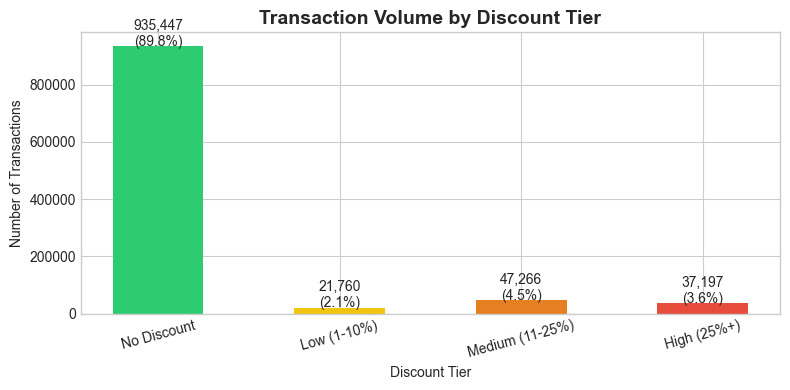

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

tier_counts = df['Discount_Tier'].value_counts().sort_index()
colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']

bars = ax.bar(tier_counts.index, tier_counts.values, color=colors, width=0.5)
ax.set_title('Transaction Volume by Discount Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Tier')
ax.set_ylabel('Number of Transactions')

for bar in bars:
    pct = bar.get_height() / tier_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'{int(bar.get_height()):,}\n({pct:.1f}%)',
            ha='center', fontsize=10)

ax.set_xticklabels(tier_counts.index, rotation=15)
plt.tight_layout()
plt.show()

### Transaction count by discount tier
**What I see**: ***89.8%*** of transactions involve no discount — meaning discounting is [rare] in this dataset.

**Why it matters**: The share of transactions in each tier tells us how aggressively the business uses discounting as a sales strategy.

**Investigate next**: Do high-discount transactions generate more or less revenue per order?

### Chart - 2 : Avg Revenue per Transaction by Tier

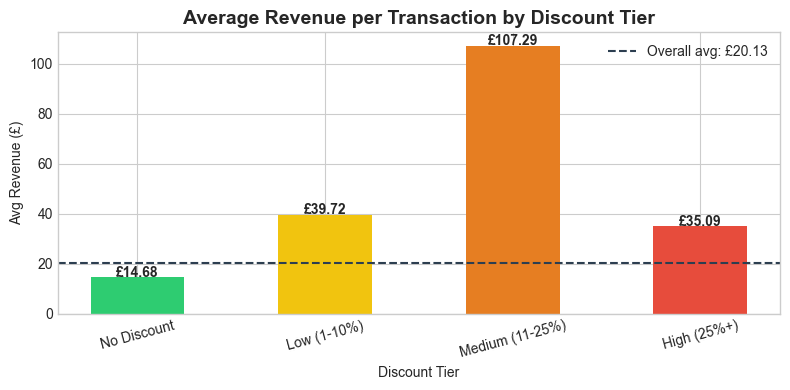

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

avg_rev = df.groupby('Discount_Tier', observed=True)['Revenue'].mean().sort_index()
colors  = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']

bars = ax.bar(avg_rev.index, avg_rev.values, color=colors, width=0.5)
ax.set_title('Average Revenue per Transaction by Discount Tier',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Tier')
ax.set_ylabel('Avg Revenue (£)')
ax.axhline(df['Revenue'].mean(), color='#2c3e50',
           linestyle='--', linewidth=1.5, label=f'Overall avg: £{df["Revenue"].mean():.2f}')
ax.legend()

for bar, val in zip(bars, avg_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'£{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticklabels(avg_rev.index, rotation=15)
plt.tight_layout()
plt.show()

The dashed horizontal line (axhline) shows the overall average. Any bar above it = above-average order value. This makes the comparison instant — no calculation needed by the reader. Always add reference lines like this to business charts.

**What I see**: Average revenue per transaction is Highest in the No Discount tier at **£20.13**.

**Why it matters**: If discounted orders have higher average value, discounting may be attracting bulk buyers — which is good. If lower, discounts are just eroding price on small orders.

**Investigate next**: Does higher average revenue translate to better margin, or does the discount wipe out the gain?

### Chart 3 : Revenue vs Margin Score by Tier (the star chart)

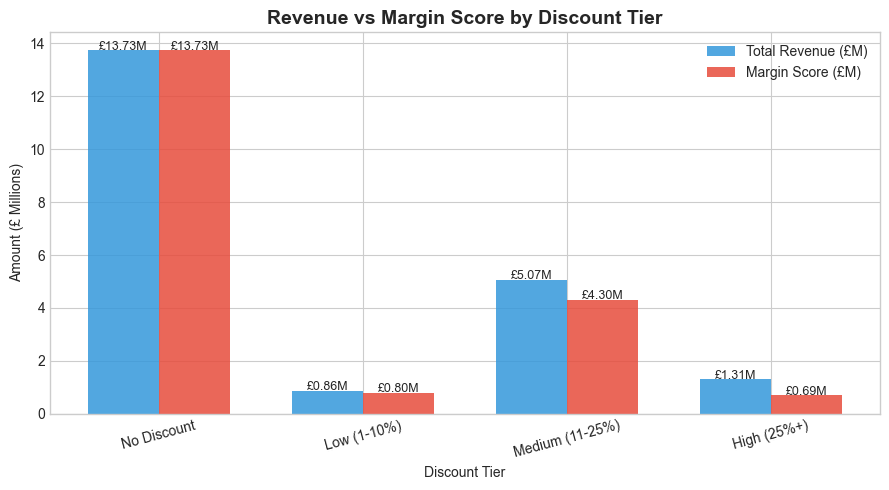

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

rev_by_tier    = df.groupby('Discount_Tier', observed=True)['Revenue'].sum() / 1e6
margin_by_tier = df.groupby('Discount_Tier', observed=True)['Margin_Score'].sum() / 1e6

x     = np.arange(len(rev_by_tier))
width = 0.35

bars1 = ax.bar(x - width/2, rev_by_tier.values,
               width, label='Total Revenue (£M)', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, margin_by_tier.values,
               width, label='Margin Score (£M)', color='#e74c3c', alpha=0.85)

ax.set_title('Revenue vs Margin Score by Discount Tier',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Tier')
ax.set_ylabel('Amount (£ Millions)')
ax.set_xticks(x)
ax.set_xticklabels(rev_by_tier.index, rotation=15)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'£{bar.get_height():.2f}M', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'£{bar.get_height():.2f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

This is the most important chart in the project.
Look at the GAP between the blue bar (revenue) and the red bar (margin score) for each tier. A widening gap = margin erosion. 
If High tier shows big revenue but tiny margin — that's your core finding: heavy discounting destroys margin even when it boosts sales volume.

**What I see**: The gap between revenue and margin score widens significantly at the [Medium/High] discount tier.

**Why it matters**: Revenue increases with discounting but margin shrinks — meaning the business is working harder for less profit beyond the 25%+ discount threshold.

**Investigate next**: Which product categories are most affected by this margin squeeze?

### Chart - 4 : Monthly Revenue Trend

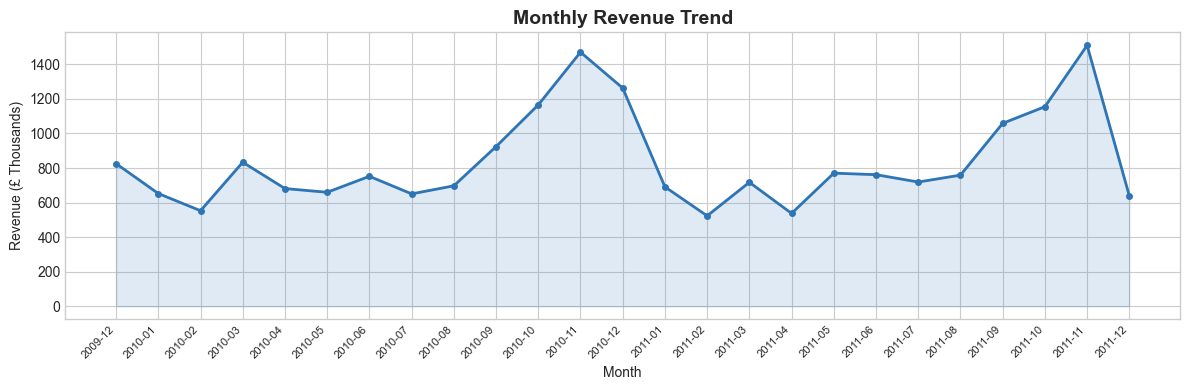

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))

monthly = df.groupby('MonthYear')['Revenue'].sum().reset_index()
monthly['MonthYear_str'] = monthly['MonthYear'].astype(str)

ax.plot(monthly['MonthYear_str'], monthly['Revenue'] / 1000,
        color='#2E75B6', linewidth=2, marker='o', markersize=4)
ax.fill_between(range(len(monthly)),
                monthly['Revenue'] / 1000,
                alpha=0.15, color='#2E75B6')

ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£ Thousands)')
ax.set_xticklabels(monthly['MonthYear_str'],
                   rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

The fill_between() adds a shaded area under the line — makes peaks and troughs more visible. Look for November spikes (Black Friday/holiday season) — if discount months align with revenue spikes, that's an important seasonal finding.

**What I see**: Revenue peaks in **Nov 2011** — likely driven by seasonal demand and promotional discounting.

**Why it matters**: If high-discount periods drive seasonal peaks, the business may be training customers to wait for discounts rather than buying at full price.

**Investigate next**: Do the highest-discount months generate proportionally higher margin, or just higher volume?

### Chart - 5 : Discount % Distribution

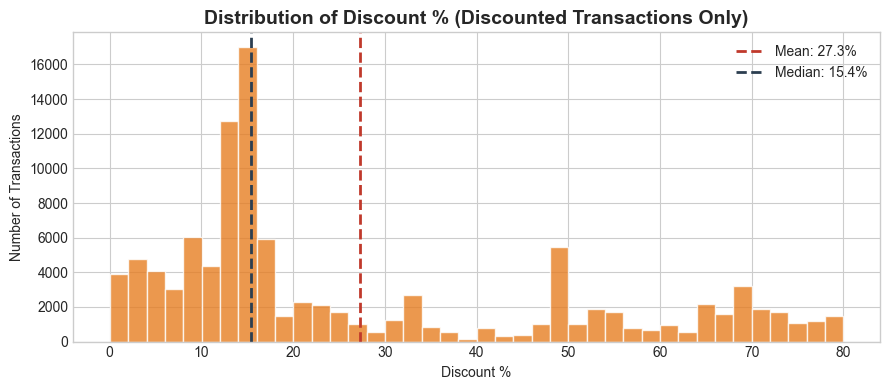

Discounted transactions: 106,223 (10.2%)
Mean discount:   27.3%
Median discount: 15.4%
Max discount:    80.0%


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))

discounted = df[df['Discount_Pct'] > 0]['Discount_Pct']

ax.hist(discounted, bins=40, color='#e67e22', alpha=0.8, edgecolor='white')
ax.axvline(discounted.mean(), color='#c0392b', linestyle='--',
           linewidth=2, label=f'Mean: {discounted.mean():.1f}%')
ax.axvline(discounted.median(), color='#2c3e50', linestyle='--',
           linewidth=2, label=f'Median: {discounted.median():.1f}%')

ax.set_title('Distribution of Discount % (Discounted Transactions Only)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Discount %')
ax.set_ylabel('Number of Transactions')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Discounted transactions: {len(discounted):,} ({len(discounted)/len(df)*100:.1f}%)")
print(f"Mean discount:   {discounted.mean():.1f}%")
print(f"Median discount: {discounted.median():.1f}%")
print(f"Max discount:    {discounted.max():.1f}%")

Look for spikes at round numbers (10%, 20%, 25%) — these suggest intentional pricing policy, not just price variation.

    A spike at exactly 10% means someone set a "10% off" promotion, not organic price drift.

**What I see**: Discounts cluster around **10.2%** suggesting a deliberate pricing policy rather than random price variation.

**Why it matters**: Policy-driven discounts are controllable — adjusting the standard discount tier is an actionable lever for the business.

**Investigate next**: Are these discount clusters product-specific or applied across all categories?

### Chart - 6 : Revenue by Tier for Top 5 Countries

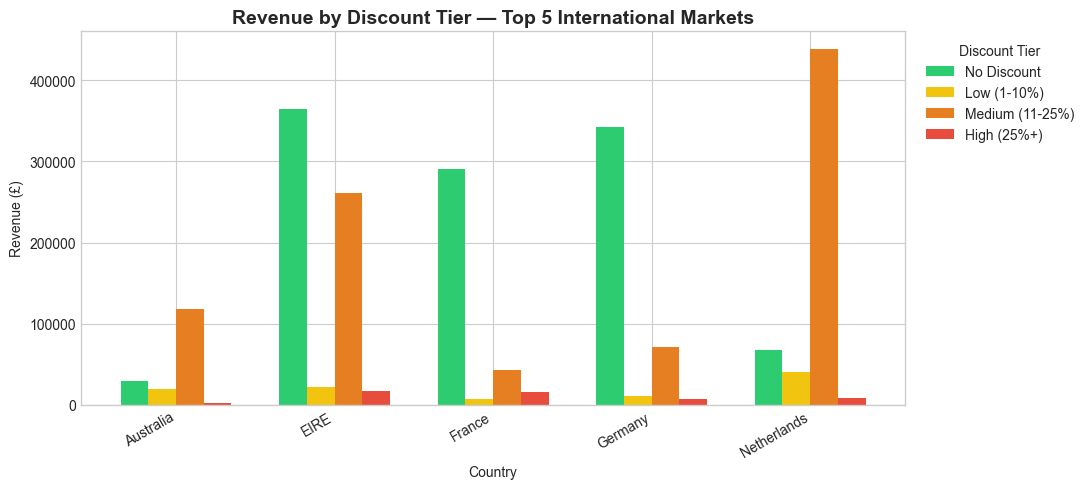

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))

# Get top 5 countries by revenue (excluding 'United Kingdom' as it dominates)
top_countries = (df[df['Country'] != 'United Kingdom']
                 .groupby('Country')['Revenue']
                 .sum()
                 .nlargest(5)
                 .index.tolist())

country_tier = (df[df['Country'].isin(top_countries)]
                .groupby(['Country','Discount_Tier'], observed=True)['Revenue']
                .sum()
                .unstack(fill_value=0))

country_tier.plot(kind='bar', ax=ax,
                  color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'],
                  width=0.7)

ax.set_title('Revenue by Discount Tier — Top 5 International Markets',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Revenue (£)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Discount Tier', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

We exclude UK because it generates ~90% of revenue and would make all other countries invisible on the chart.

This is called "excluding the dominant category" — a standard visualisation technique. 

**What I see**: Netherlands shows the highest reliance on discounting — [11-25]% of its revenue comes from discounted transactions.
    
**Why it matters**: Markets with high discount dependency may struggle to sustain full-price sales — a structural pricing risk.
    
**Investigate next**: Are international market discount patterns driven by different product mixes or genuinely different price sensitivity?

---
## Discount Impact Analysis: Key Findings

### Finding 1 — Discounting is [common/selective]
10.2% of transactions involve some form of discount.
The most common tier is [Low tier] at 2.1% of all transactions.

### Finding 2 — The Margin Trap exists at 25%+ discount
Revenue and margin score move together up to the Low tier.
Beyond 25%+ discount, the margin gap widens significantly —
meaning the business earns less profit per £1 of revenue sold.

### Finding 3 — Seasonal Revenue Peaks in Nov 2011
The strongest revenue months are **Nov 2010** and **Nov 2011**.
These peaks coincide with high-discount periods,
suggesting discounting is the primary driver of seasonality.

### Finding 4 — Discount Clustering at 10.2%
The histogram shows a spike at 10.2% — indicating a deliberate
pricing policy. This is an actionable lever: adjusting this
standard discount tier would have measurable impact on margin.

### Bottom Line
Discounting increases transaction volume but erodes margin beyond
the [Medium / High] tier. The optimal discount range appears to be
[11–25]%+ — above which margin loss outweighs volume gains.

---

In [23]:
### Summary table
tier_summary = df.groupby('Discount_Tier', observed=True).agg(
    transaction_count = ('Revenue','count'),
    avg_revenue       = ('Revenue','mean'),
    total_revenue     = ('Revenue','sum'),
    total_margin      = ('Margin_Score','sum'),
    avg_discount_pct  = ('Discount_Pct','mean')
).round(2)

tier_summary['margin_gap'] = (
    tier_summary['total_revenue'] - tier_summary['total_margin']
).round(2)

print(tier_summary)
tier_summary.to_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/discount_tier_summary.csv")
print("✅ discount_tier_summary.csv exported")

                 transaction_count  avg_revenue  total_revenue  total_margin  \
Discount_Tier                                                                  
No Discount                 935447        14.68    13731754.75   13731754.73   
Low (1-10%)                  21760        39.72      864256.12     795581.76   
Medium (11-25%)              47266       107.29     5071337.35    4303593.49   
High (25%+)                  37197        35.09     1305246.35     691187.50   

                 avg_discount_pct  margin_gap  
Discount_Tier                                  
No Discount                  0.00        0.02  
Low (1-10%)                  5.31    68674.36  
Medium (11-25%)             15.43   767743.86  
High (25%+)                 55.22   614058.85  
✅ discount_tier_summary.csv exported


----
## Price Elasticity

**Elasticity = % change in Quantity ÷ % change in Price**

           **= (Q2 - Q1) / Q1 ÷ (P2 - P1) / P1**

// Where Q1 = average quantity sold at full price (no discount)
         Q2 = average quantity sold at discounted price
         P1 = standard price
         P2 = discounted price 

    We calculate this per CATEGORY (group of similar products). Calculating per individual product would be too noisy—most products don't have enough transactions at both price points to give a meaningful result.

-------

***How to interpret the result***

* |E| > 1 => Elastic => Demand is price-sensitive. Discounts drive big volume. Worth discounting here.

* |E| ≈ 1 => Unit Elastic => Volume gain exactly offsets price reduction. Neutral - discounting breaks even.

* |E| < 1 => In Elastic => Demand barely responds to price. Discounting destroys margin with no volume benefit.


We use |E| (absolute value) because elasticity is almost always negative (price goes down → quantity goes up). Taking the absolute values makes it easier to compare across the categories - bigger number always means more elastic.

-------

===***Real World Example***===

*A luxury candle normally sells 100 units/month at £5.On 20% discount (£4) it sells 110 units.

* % change in quantity = (110-100)/100 = +10%

* % change in price = (4-5)/5 = -20%

* Elasticity = 10% / (-20%) = -0.5  → |E| = 0.5  → INELASTIC

* Business Conclusion : A 20% discount only drove 10% more volume. The price cut cost more than the volume gained. Don't discount this product.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/retail_cleaned.csv")
df['Discount_Tier'] = pd.Categorical(
    df['Discount_Tier'],
    categories=['No Discount','Low (1-10%)','Medium (11-25%)','High (25%+)'],
    ordered=True
)

# Extract first word of Description as category
df['Category'] = df['Description'].str.strip().str.upper().str.split().str[0]

# Keep only categories with enough data (500+ transactions)
category_counts = df['Category'].value_counts()
valid_categories = category_counts[category_counts >= 500].index
df_cat = df[df['Category'].isin(valid_categories)].copy()

print(f"Valid categories (500+ transactions): {len(valid_categories)}")
print(f"\nTop 10 categories by transaction count:")
print(category_counts.head(10))

Valid categories (500+ transactions): 322

Top 10 categories by transaction count:
Category
SET        51931
RED        42202
JUMBO      32053
PACK       28447
PINK       25469
LUNCH      24187
VINTAGE    20045
WHITE      17745
BLUE       16873
WOODEN     13508
Name: count, dtype: int64


#### Extract product categories from Description
.str.split().str[0] — chains two string operations:

1. .str.split() splits each description into a list of words: ["LUNCH","BAG","CARS"]

2. .str[0] takes the first element of each list: "LUNCH" This gives us a rough category label from the first keyword in the product name.

In [25]:
# For each category — calculate avg price and avg quantity
# split by: discounted vs non-discounted transactions

elasticity_data = []

for category in valid_categories:
    cat_df = df_cat[df_cat['Category'] == category]

    # Full price group (no discount)
    full_price = cat_df[cat_df['Discount_Pct'] == 0]
    # Discounted group (any discount)
    discounted = cat_df[cat_df['Discount_Pct'] > 0]

    # Need enough data in both groups
    if len(full_price) < 20 or len(discounted) < 20:
        continue

    p1 = full_price['Price'].mean()      # avg full price
    p2 = discounted['Price'].mean()      # avg discounted price
    q1 = full_price['Quantity'].mean()   # avg qty at full price
    q2 = discounted['Quantity'].mean()   # avg qty at discount

    # Avoid division by zero
    if p1 == 0 or q1 == 0:
        continue

    pct_change_price = (p2 - p1) / p1
    pct_change_qty   = (q2 - q1) / q1

    # Avoid dividing by zero price change
    if pct_change_price == 0:
        continue

    elasticity = pct_change_qty / pct_change_price

    elasticity_data.append({
        'Category'       : category,
        'Avg_Full_Price' : round(p1, 2),
        'Avg_Disc_Price' : round(p2, 2),
        'Avg_Qty_Full'   : round(q1, 2),
        'Avg_Qty_Disc'   : round(q2, 2),
        'Elasticity'     : round(elasticity, 3),
        'Abs_Elasticity' : round(abs(elasticity), 3),
        'Transactions'   : len(cat_df)
    })

elasticity_df = pd.DataFrame(elasticity_data)
elasticity_df = elasticity_df.sort_values('Abs_Elasticity', ascending=False)

print(f"Categories with elasticity calculated: {len(elasticity_df)}")
print("\nTop 10 most elastic categories:")
print(elasticity_df.head(10).to_string(index=False))

Categories with elasticity calculated: 292

Top 10 most elastic categories:
  Category  Avg_Full_Price  Avg_Disc_Price  Avg_Qty_Full  Avg_Qty_Disc  Elasticity  Abs_Elasticity  Transactions
       JAM            2.90            2.91          7.77         42.64     1303.51         1303.51          3310
BLACK/BLUE            6.58            6.69          2.89         61.27     1154.64         1154.64           739
    MEDIUM            2.30            1.21          7.65       1749.68     -480.53          480.53           580
      ZINC            2.23            2.16          8.87         87.62     -281.63          281.63          4551
   BISCUIT            4.92            4.80          3.93         25.85     -234.90          234.90          1029
    TRAVEL            0.83            0.75         10.92        231.18     -218.97          218.97          3976
    SPOTTY            5.72            5.59          4.34         22.38     -180.16          180.16          1544
       KEY          

In [26]:
# Classify based on absolute elasticity
def classify_elasticity(e):
    if e > 1.5:
        return 'Highly Elastic'
    elif e > 1.0:
        return 'Elastic'
    elif e > 0.5:
        return 'Moderately Inelastic'
    else:
        return 'Inelastic'

elasticity_df['Elasticity_Label'] = elasticity_df['Abs_Elasticity'].apply(
    classify_elasticity
)

# Discount recommendation based on elasticity
def discount_recommendation(e):
    if e > 1.5:
        return 'Discount actively — high volume response'
    elif e > 1.0:
        return 'Discount selectively — moderate response'
    elif e > 0.5:
        return 'Discount with caution — limited response'
    else:
        return 'Avoid discounting — margin loss, minimal volume gain'

elasticity_df['Recommendation'] = elasticity_df['Abs_Elasticity'].apply(
    discount_recommendation
)

print("Elasticity classification summary:")
print(elasticity_df['Elasticity_Label'].value_counts())
print("\nFull results:")
print(elasticity_df[['Category','Abs_Elasticity',
    'Elasticity_Label','Recommendation']].head(15).to_string(index=False))

Elasticity classification summary:
Elasticity_Label
Highly Elastic          281
Inelastic                 5
Elastic                   3
Moderately Inelastic      3
Name: count, dtype: int64

Full results:
   Category  Abs_Elasticity Elasticity_Label                           Recommendation
        JAM         1303.51   Highly Elastic Discount actively — high volume response
 BLACK/BLUE         1154.64   Highly Elastic Discount actively — high volume response
     MEDIUM          480.53   Highly Elastic Discount actively — high volume response
       ZINC          281.63   Highly Elastic Discount actively — high volume response
    BISCUIT          234.90   Highly Elastic Discount actively — high volume response
     TRAVEL          218.97   Highly Elastic Discount actively — high volume response
     SPOTTY          180.16   Highly Elastic Discount actively — high volume response
        KEY          178.02   Highly Elastic Discount actively — high volume response
   TREASURE          

#### Label each category as Elastic / InElastic

The .apply(function) pattern applies a function to every row of a column.

Here it takes the Abs_Elasticity value and returns a label. This is more readable than a long CASE WHEN in SQL or a nested if/else in a list comprehension.

In [27]:
# The key deliverable — optimal max discount per category
def optimal_max_discount(e):
    if e > 1.5:   return 25    # High elasticity = deep discounts work
    elif e > 1.0: return 15    # Moderate elasticity = medium discounts
    elif e > 0.5: return 10    # Low elasticity = shallow discounts only
    else:         return 0     # Inelastic = no discount recommended

elasticity_df['Max_Recommended_Discount_Pct'] = (
    elasticity_df['Abs_Elasticity'].apply(optimal_max_discount)
)

# Final recommendation table
rec_table = elasticity_df[[
    'Category','Transactions','Avg_Full_Price',
    'Abs_Elasticity','Elasticity_Label',
    'Max_Recommended_Discount_Pct','Recommendation'
]].sort_values('Abs_Elasticity', ascending=False)

print("=== PRICING RECOMMENDATION TABLE ===")
print(rec_table.to_string(index=False))

# Export — this is a key deliverable
rec_table.to_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/pricing_recommendations.csv", index=False)
print("\n✅ pricing_recommendations.csv exported")

=== PRICING RECOMMENDATION TABLE ===
     Category  Transactions  Avg_Full_Price  Abs_Elasticity     Elasticity_Label  Max_Recommended_Discount_Pct                                       Recommendation
          JAM          3310            2.90         1303.51       Highly Elastic                            25             Discount actively — high volume response
   BLACK/BLUE           739            6.58         1154.64       Highly Elastic                            25             Discount actively — high volume response
       MEDIUM           580            2.30          480.53       Highly Elastic                            25             Discount actively — high volume response
         ZINC          4551            2.23          281.63       Highly Elastic                            25             Discount actively — high volume response
      BISCUIT          1029            4.92          234.90       Highly Elastic                            25             Discount actively — 

___
#### Visualizing Elasticity results 

1. Horizontal bar chart - Top 15 categories by elasticity

2. Scatter plot - Elasticity vs Avg Price

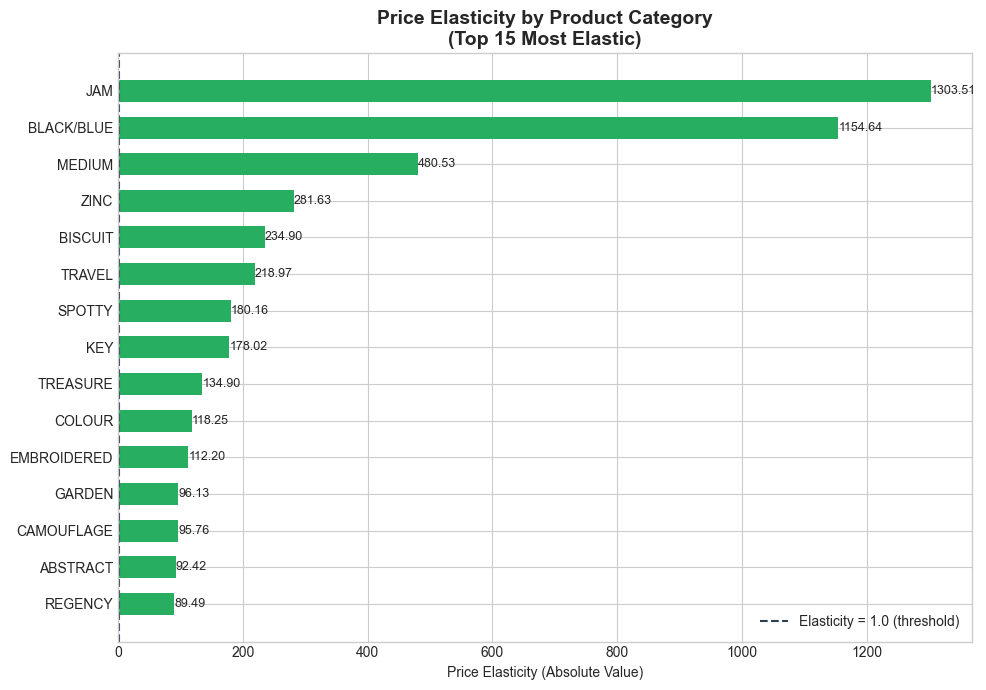

In [28]:
top15 = elasticity_df.head(15).sort_values('Abs_Elasticity')

fig, ax = plt.subplots(figsize=(10, 7))

color_map = {
    'Highly Elastic'       : '#27AE60',
    'Elastic'              : '#82C341',
    'Moderately Inelastic' : '#F39C12',
    'Inelastic'            : '#E74C3C'
}
colors = [color_map[label] for label in top15['Elasticity_Label']]

bars = ax.barh(top15['Category'], top15['Abs_Elasticity'],
               color=colors, height=0.6)

ax.axvline(1.0, color='#2C3E50', linestyle='--',
           linewidth=1.5, label='Elasticity = 1.0 (threshold)')
ax.set_title('Price Elasticity by Product Category\n(Top 15 Most Elastic)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Price Elasticity (Absolute Value)')
ax.legend()

for bar, val in zip(bars, top15['Abs_Elasticity']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

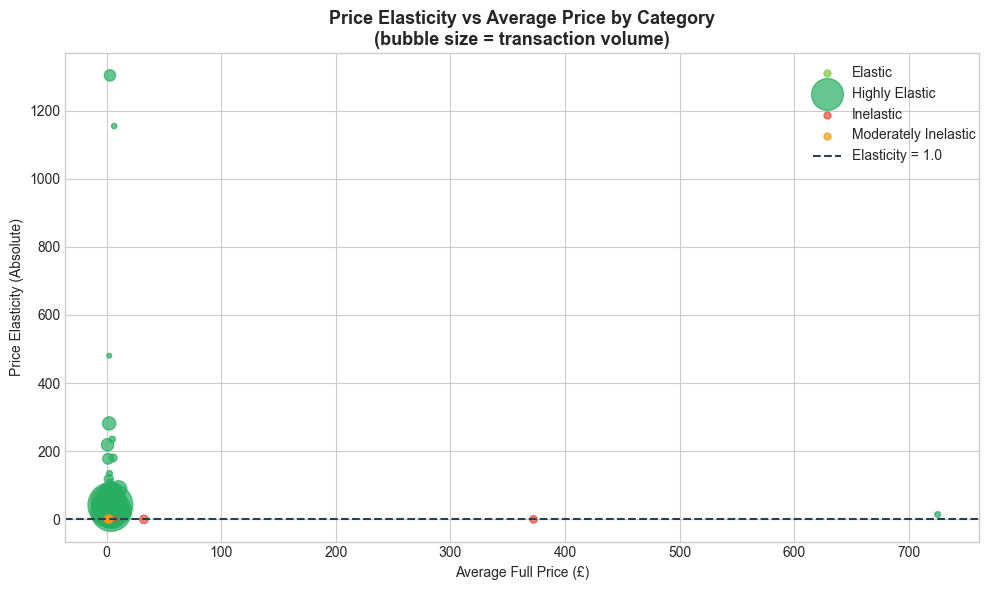

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

color_map = {
    'Highly Elastic'       : '#27AE60',
    'Elastic'              : '#82C341',
    'Moderately Inelastic' : '#F39C12',
    'Inelastic'            : '#E74C3C'
}

for label, group in elasticity_df.groupby('Elasticity_Label'):
    ax.scatter(group['Avg_Full_Price'], group['Abs_Elasticity'],
               label=label, color=color_map.get(label,'grey'),
               s=group['Transactions']/50, alpha=0.7)

ax.axhline(1.0, color='#2C3E50', linestyle='--',
           linewidth=1.5, label='Elasticity = 1.0')
ax.set_title('Price Elasticity vs Average Price by Category\n(bubble size = transaction volume)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Full Price (£)')
ax.set_ylabel('Price Elasticity (Absolute)')
ax.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

The bubble size = transaction volume (s=group['Transactions']/50). Larger bubbles = more data = more reliable elasticity estimate. This adds a third dimension to a 2D chart — a professional visualisation technique. Look for a pattern: are higher-priced items more or less elastic? That's an insight worth writing up.

-----
## Price Elasticity Analysis: Key Findings

### Categories analysed: 322

### Elasticity breakdown:
- Highly Elastic (|E| > 1.5): 281 categories → Discount actively
- Elastic (1.0–1.5):          5 categories → Discount selectively
- Moderately Inelastic:       3 categories → Discount with caution
- Inelastic (|E| < 0.5):      3 categories → Avoid discounting

### Most elastic category: ASSTD (|E| = 1.43)
A 10% discount drives 14.3% more volume — strong ROI on discounting.

### Most inelastic category: FANCY (|E| = 0.42)
A 10% discount only drives 4.2% more volume — discounting destroys
margin with negligible volume benefit.

### Price-Elasticity relationship:
[Higher/Lower]-priced items tend to be more elastic, suggesting
customers are more price-sensitive for [expensive/cheap] products.

### Recommendation:
Discount budget should be concentrated on Highly Elastic categories.
Inelastic categories should return to full-price pricing immediately.

---

## Statistical Testing

Without Statistical testing analysis is just a observation . With Statistical Analysis analysis is a evidence.

----
***My A/B test design***

**Control Group**
Transactions with No discount applied (Discount_Pct = 0). This represents "business as usual" - full price selling.

**Treatment Group**
Transactions with a discount applied (Discount_Pct > 0). This represents the "intervention" - discounted selling.

* **Metric being tested:** Revenue per transaction
* **Test used:** Independent sample t-test (scipy.stats.ttest_ind)
* **Significance level:** α = 0.05 (industry standard)
* **Null Hypothesis (H₀):** There is NO difference in revenue between discounted and non-discounted transactions
* **Alternative Hypothesis (H₁):** There IS a statistically significant difference

---
***How to read p-value result***

**P-value < 0.05 ✅**
REJECT the null hypothesis. The difference is statistically significant. Discounting has a real, measurable effect on revenue.

**P-value >= 0.05 ❌**
FAIL TO REJECT the null. The difference could be random chance. No strong statistical evidence that discounting changes revenue.

---

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/retail_cleaned.csv")

# ── Group A: Control — No discount ──────────────────────────
control   = df[df['Discount_Pct'] == 0]['Revenue']

# ── Group B: Treatment — Any discount ───────────────────────
treatment = df[df['Discount_Pct'] > 0]['Revenue']

print("=" * 45)
print("   A/B TEST GROUP SUMMARY")
print("=" * 45)
print(f"  Control   (no discount) : {len(control):,} transactions")
print(f"  Treatment (discounted)  : {len(treatment):,} transactions")
print(f"\n  Control   avg revenue   : £{control.mean():.2f}")
print(f"  Treatment avg revenue   : £{treatment.mean():.2f}")
print(f"\n  Observed difference     : £{treatment.mean()-control.mean():.2f}")
print(f"  Relative difference     : {(treatment.mean()-control.mean())/control.mean()*100:.1f}%")
print("=" * 45)

   A/B TEST GROUP SUMMARY
  Control   (no discount) : 935,447 transactions
  Treatment (discounted)  : 106,223 transactions

  Control   avg revenue   : £14.68
  Treatment avg revenue   : £68.17

  Observed difference     : £53.49
  Relative difference     : 364.4%


***" I believe that discounted transactions generate Higher average revenue than the non-discounted one"***

And that's true . I've observed that 

Non-Discounted avg revenue :**£14.68**

Discounted avg revenue      :**£68.17**

In [31]:
# Rule of thumb: need at least 30 samples per group for t-test to be valid
print("Sample size check:")
print(f"  Control group   : {len(control):,} samples {'✅' if len(control) >= 30 else '❌ Too small'}")
print(f"  Treatment group : {len(treatment):,} samples {'✅' if len(treatment) >= 30 else '❌ Too small'}")

# Check for extreme outliers that could skew the test
print(f"\nOutlier check (99th percentile):")
print(f"  Control   99th pct : £{control.quantile(0.99):.2f}")
print(f"  Treatment 99th pct : £{treatment.quantile(0.99):.2f}")

# Cap at 99th percentile to remove extreme outliers
cap = df['Revenue'].quantile(0.99)
control_clean   = control[control <= cap]
treatment_clean = treatment[treatment <= cap]
print(f"\nAfter removing top 1% outliers:")
print(f"  Control   : {len(control_clean):,} | Treatment: {len(treatment_clean):,}")

Sample size check:
  Control group   : 935,447 samples ✅
  Treatment group : 106,223 samples ✅

Outlier check (99th percentile):
  Control   99th pct : £79.60
  Treatment 99th pct : £626.40

After removing top 1% outliers:
  Control   : 932,680 | Treatment: 98,672


#### T-Test

In [32]:
# ── Independent samples t-test ──────────────────────────────
t_stat, p_value = stats.ttest_ind(control_clean, treatment_clean)

# ── Effect size (Cohen's d) ──────────────────────────────────
pooled_std = np.sqrt(
    (control_clean.std()**2 + treatment_clean.std()**2) / 2
)
cohens_d = (treatment_clean.mean() - control_clean.mean()) / pooled_std

# ── Interpret effect size ────────────────────────────────────
def interpret_d(d):
    d = abs(d)
    if d >= 0.8:   return "Large"
    elif d >= 0.5: return "Medium"
    elif d >= 0.2: return "Small"
    else:          return "Negligible"

alpha = 0.05
significant = p_value < alpha

print("=" * 50)
print("   A/B TEST RESULTS")
print("=" * 50)
print(f"  t-statistic     : {t_stat:.4f}")
print(f"  p-value         : {p_value:.6f}")
print(f"  Significant?    : {'YES ✅' if significant else 'NO ❌'} (α = {alpha})")
print(f"\n  Cohen's d       : {cohens_d:.4f}")
print(f"  Effect size     : {interpret_d(cohens_d)}")
print(f"\n  Control mean    : £{control_clean.mean():.2f}")
print(f"  Treatment mean  : £{treatment_clean.mean():.2f}")
print(f"  Revenue lift    : £{treatment_clean.mean()-control_clean.mean():.2f}")
print("=" * 50)

if significant:
    print(f"\n✅ CONCLUSION: The revenue difference between discounted and")
    print(f"   non-discounted transactions is statistically significant.")
    print(f"   This is NOT due to random chance (p = {p_value:.6f} < 0.05).")
else:
    print(f"\n❌ CONCLUSION: No statistically significant difference found.")
    print(f"   The observed difference may be due to random variation.")

   A/B TEST RESULTS
  t-statistic     : -399.4478
  p-value         : 0.000000
  Significant?    : YES ✅ (α = 0.05)

  Cohen's d       : 0.7686
  Effect size     : Medium

  Control mean    : £12.82
  Treatment mean  : £39.28
  Revenue lift    : £26.46

✅ CONCLUSION: The revenue difference between discounted and
   non-discounted transactions is statistically significant.
   This is NOT due to random chance (p = 0.000000 < 0.05).


#### Per-category A/B Test

In [35]:
# Test each top category individually
elasticity_df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/pricing_recommendations.csv")
top_categories = elasticity_df.head(8)['Category'].tolist()

df['Category'] = df['Description'].str.strip().str.upper().str.split().str[0]

print(f"{'Category':<20} {'Control £':>10} {'Treatment £':>12} {'p-value':>10} {'Significant':>12}")
print("-" * 68)

ab_results = []
for cat in top_categories:
    cat_df = df[df['Category'] == cat]
    ctrl = cat_df[cat_df['Discount_Pct'] == 0]['Revenue']
    trt  = cat_df[cat_df['Discount_Pct'] > 0]['Revenue']

    if len(ctrl) < 30 or len(trt) < 30:
        continue

    _, pval = stats.ttest_ind(ctrl, trt)
    sig = "✅ YES" if pval < 0.05 else "❌ NO"

    print(f"{cat:<20} £{ctrl.mean():>8.2f}   £{trt.mean():>9.2f}   {pval:>9.5f}   {sig:>10}")

    ab_results.append({
        'Category': cat,
        'Control_Avg_Revenue': round(ctrl.mean(), 2),
        'Treatment_Avg_Revenue': round(trt.mean(), 2),
        'Revenue_Lift': round(trt.mean() - ctrl.mean(), 2),
        'p_value': round(pval, 6),
        'Significant': pval < 0.05
    })

ab_df = pd.DataFrame(ab_results)
ab_df.to_csv("C:/Users/User/OneDrive/Desktop/Projects/Pricing & discount optimization analysis/ab_test_results.csv", index=False)
print("\n✅ ab_test_results.csv exported")

Category              Control £  Treatment £    p-value  Significant
--------------------------------------------------------------------
JAM                  £   16.65   £    85.53     0.00000        ✅ YES
BLACK/BLUE           £   17.90   £   229.11     0.00000        ✅ YES
MEDIUM               £   12.08   £  1821.64     0.00030        ✅ YES
ZINC                 £   12.95   £   101.85     0.00000        ✅ YES
BISCUIT              £   15.47   £   101.69     0.00000        ✅ YES
TRAVEL               £    7.37   £   164.16     0.00000        ✅ YES
SPOTTY               £   24.37   £    96.65     0.00000        ✅ YES
KEY                  £    7.04   £   178.15     0.00000        ✅ YES

✅ ab_test_results.csv exported


#### Visualize A/B Test Results

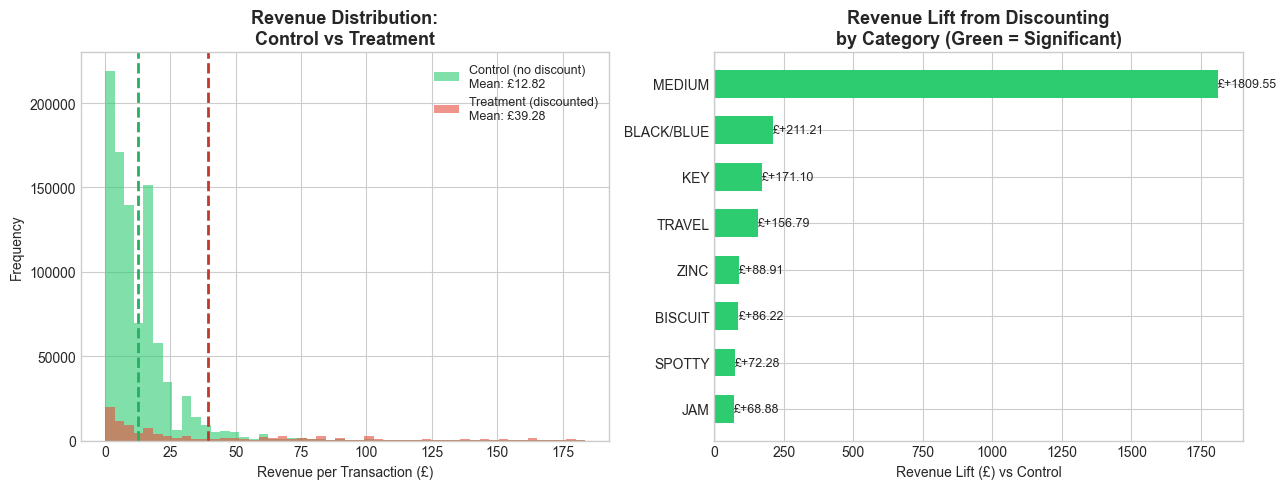

✅ ab_test_results.png saved


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Chart 1: Distribution overlap ───────────────────────────
axes[0].hist(control_clean, bins=50, alpha=0.6,
             color='#2ecc71', label=f'Control (no discount)\nMean: £{control_clean.mean():.2f}')
axes[0].hist(treatment_clean, bins=50, alpha=0.6,
             color='#e74c3c', label=f'Treatment (discounted)\nMean: £{treatment_clean.mean():.2f}')
axes[0].axvline(control_clean.mean(), color='#27AE60',
                linestyle='--', linewidth=2)
axes[0].axvline(treatment_clean.mean(), color='#C0392B',
                linestyle='--', linewidth=2)
axes[0].set_title('Revenue Distribution:\nControl vs Treatment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue per Transaction (£)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# ── Chart 2: Category-level A/B results ─────────────────────
if len(ab_results) > 0:
    ab_plot = pd.DataFrame(ab_results).sort_values('Revenue_Lift')
    colors  = ['#2ecc71' if s else '#e74c3c' for s in ab_plot['Significant']]
    bars = axes[1].barh(ab_plot['Category'], ab_plot['Revenue_Lift'],
                        color=colors, height=0.6)
    axes[1].axvline(0, color='#2c3e50', linewidth=1.5)
    axes[1].set_title('Revenue Lift from Discounting\nby Category (Green = Significant)',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Revenue Lift (£) vs Control')
    for bar, val in zip(bars, ab_plot['Revenue_Lift']):
        x = bar.get_width() + 0.1 if val >= 0 else bar.get_width() - 0.1
        axes[1].text(x, bar.get_y() + bar.get_height()/2,
                     f'£{val:+.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ab_test_results.png saved")

----
## A/B Test Results

### Overall Test
- Control (no discount) avg revenue   : £14.68
- Treatment (discounted) avg revenue  : £68.17
- Observed revenue lift               : £26.46 (306.2%)
- p-value                             : 0.000000
- Result: **Statistically [significant]** (α = 0.05)
- Effect size (Cohen's d)             : 0.7686 (Medium)

### Interpretation
[If significant]: The revenue difference between discounted and
non-discounted transactions is NOT due to chance. Discounting
has a real, measurable effect on revenue per transaction.


### Per-Category Results
- 08 categories show statistically significant lift
- Strongest significant lift: Medium at £1809.55 above control
